**Paso 1:** Carga de datos y primera mirada

La idea es construir un modelo que prediga el promedio del semestre (Sem_GPA) a partir de otros datos del estudiante.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/gabrielasbacchiani/aprendizaje_automatico/refs/heads/main/CLASE4_AA/DATASETS/Actividad1_academic_survival_longitudinal.csv'
df = pd.read_csv(url)

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79239 entries, 0 to 79238
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               79239 non-null  object 
 1   Age                      79239 non-null  int64  
 2   Gender                   79239 non-null  object 
 3   First_Generation         79239 non-null  int64  
 4   Family_Income            75635 non-null  float64
 5   Household_Size           79239 non-null  int64  
 6   Housing_Status           79239 non-null  object 
 7   Scholarship              79239 non-null  int64  
 8   Tuition_Base             79239 non-null  int64  
 9   Semester                 79239 non-null  int64  
 10  Course_Load              79239 non-null  int64  
 11  Work_Hours               79239 non-null  float64
 12  Emergency_Expense        79239 non-null  float64
 13  Sem_GPA                  79239 non-null  float64
 14  Attendance            

,Age,First_Generation,Family_Income,Household_Size,Scholarship,Tuition_Base,Semester,Course_Load,Work_Hours,Emergency_Expense,Sem_GPA,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Target_Dropout_Next_Sem,Censored
count,79239.000000,79239.000000,75635.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,78372.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000
mean,19.492005,0.327894,61518.384346,3.187547,0.277515,24775.110741,3.145673,14.888615,16.936129,200.496788,2.691463,85.081599,66.375670,0.477530,0.652494,2.578287,0.087293,0.140272
std,2.139140,0.469449,39661.166570,1.332861,0.447775,10794.899387,1.946207,2.307308,10.724479,724.400513,0.422692,6.415864,12.730793,0.671954,0.786066,1.817880,0.282266,0.347271
min,17.000000,0.000000,3000.000000,1.000000,0.000000,15000.000000,1.000000,9.000000,0.000000,0.000000,0.440000,-2.000000,12.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,18.000000,0.000000,35000.000000,2.000000,0.000000,15000.000000,1.000000,12.000000,8.300000,0.000000,2.440000,81.200000,58.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,19.000000,0.000000,52000.000000,3.000000,0.000000,25000.000000,3.000000,15.000000,16.500000,0.000000,2.700000,85.200000,66.000000,0.000000,0.000000,2.100000,0.000000,0.000000
75%,21.000000,1.000000,77000.000000,4.000000,1.000000,25000.000000,4.000000,15.000000,24.900000,0.000000,2.960000,89.200000,75.000000,1.000000,1.000000,3.400000,0.000000,0.000000
max,37.000000,1.000000,488000.000000,6.000000,1.000000,45000.000000,8.000000,21.000000,40.000000,3998.000000,3.960000,105.000000,116.000000,3.000000,5.000000,18.600000,1.000000,1.000000


Se traen las tres librerías: pandas (tablas), numpy (cálculos con números) y matplotlib (gráficos).

read_csv lee el archivo y lo guarda en df, un DataFrame.

info() mostró que hay 79.239 filas y que Family_Income tiene 75.635 datos (o sea, le faltan unos 3.600) y LMS_Logins tiene 78.372 (le faltan unos 870).

**Paso 2:** Exploración de los Datos - AED

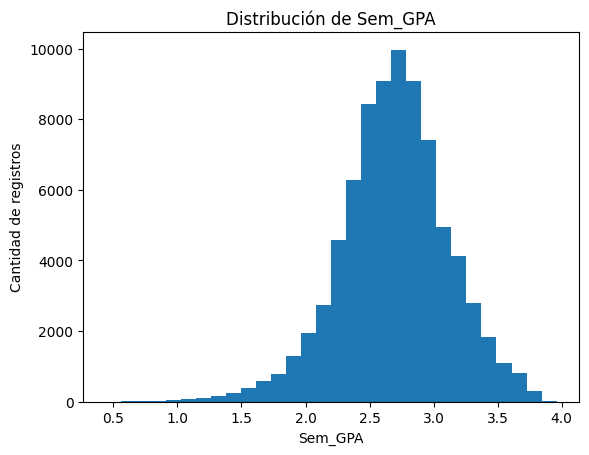

In [6]:
plt.figure()
plt.hist(df['Sem_GPA'], bins=30)
plt.title('Distribución de Sem_GPA')
plt.xlabel('Sem_GPA')
plt.ylabel('Cantidad de registros')
plt.show()

La variable a predecir (Sem_GPA) tiene forma de campana, bastante simétrica y con una leve cola hacia los promedios bajos.

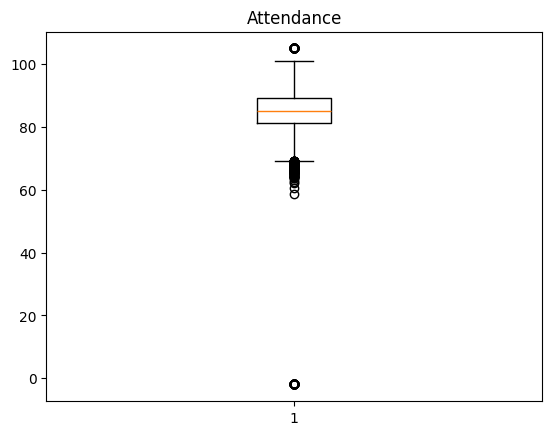

Menores a 0: 85
Mayores a 100: 164


In [7]:
plt.figure()
plt.boxplot(df['Attendance'])
plt.title('Attendance')
plt.show()

print('Menores a 0:', (df['Attendance'] < 0).sum())
print('Mayores a 100:', (df['Attendance'] > 100).sum())

El boxplot dibuja una caja con los valores "normales" y puntitos sueltos para los atípicos. La línea con print cuenta cuántas asistencias son menores a 0: df['Attendance'] < 0 da verdadero/falso para cada fila y .sum() cuenta los verdaderos. Como asistencia es un porcentaje, debería ir de 0 a 100, hay 85 valores negativos y 164 mayores a 100: son errores de carga, es decir, los "valores atípicos".

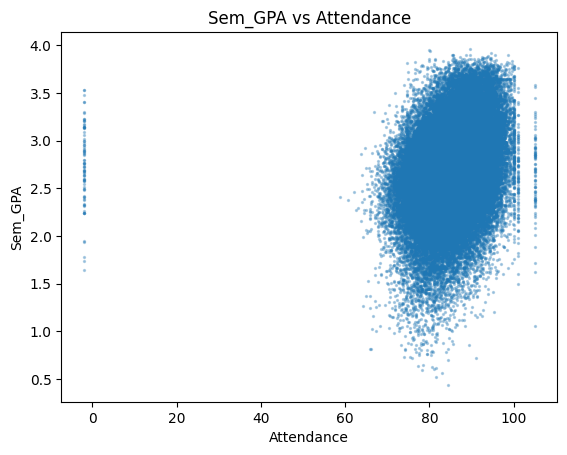

In [8]:
plt.figure()
plt.scatter(df['Attendance'], df['Sem_GPA'], s=2, alpha=0.3)
plt.xlabel('Attendance')
plt.ylabel('Sem_GPA')
plt.title('Sem_GPA vs Attendance')
plt.show()

El gráfico de dispersión pone un punto por estudiante: asistencia en el eje x, promedio en el eje y. Sirve para ver si hay una relación (por ejemplo, más asistencia → más promedio). s=2 achica los puntos y alpha=0.3 los hace transparentes para que no se tape todo con tantos datos. Se ve una relación positiva pero débil: más asistencia tiende a más promedio, con mucha dispersión alrededor.

In [10]:
columnas = ['Sem_GPA', 'Attendance', 'Work_Hours', 'LMS_Logins',
            'Advising_Visits', 'Failed_Courses', 'Financial_Stress',
            'Family_Income', 'Course_Load', 'Age']
df[columnas].corr()['Sem_GPA'].sort_values()

,Sem_GPA
Financial_Stress,-0.306829
Advising_Visits,-0.304735
Failed_Courses,-0.295609
Work_Hours,-0.241393
Course_Load,-0.153146
Age,0.001163
Family_Income,0.188036
Attendance,0.268400
LMS_Logins,0.330909
Sem_GPA,1.000000


Ninguna variable pasa de 0,33 en valor absoluto, o sea que todas las relaciones son débiles o moderadas. Ninguna variable sola alcanza para predecir el promedio (esto anticipa que el R2 no va a ser alto, en el modelo dio 0,36).

Positivas: ingresos al campus virtual (LMS_Logins, +0,33), asistencia (+0,27) e ingreso familiar (Family_Income, +0,19).

Negativas: estrés financiero (Financial_Stress, -0,31), visitas de tutoría (Advising_Visits, -0,30), materias desaprobadas (Failed_Courses, -0,30), horas de trabajo (Work_Hours, -0,24) y carga de materias (Course_Load, -0,15).

Edad (Age) tiene correlación prácticamente nula (0,001), por eso se descarta.

**Paso 3:** Limpieza de los Datos

3.1. Crear una copia para trabajar sobre ella, así el DataFrame original (df) queda intacto y siempre se puede volver atrás si algo sale mal.

In [11]:
df_limpio = df.copy()

3.2. Corregir la asistencia

Corregí la asistencia con clip porque son pocos casos y claramente con errores.

In [12]:
df_limpio['Attendance'] = df_limpio['Attendance'].clip(0, 100)

3.3. Rellenar los espacios vacíos

fillna reemplaza cada vacío por el valor que le pasás. Usamos la mediana (el valor del medio) y no el promedio porque los ingresos tienen algunos valores muy altos (hasta 488.000) que inflan el promedio (61.518) por encima de lo típico (mediana 52.000). La alternativa es eliminar las 4.431 filas con vacíos (5,6% del total); rellenar conserva más información.

In [13]:
mediana_ingreso = df_limpio['Family_Income'].median()
mediana_logins = df_limpio['LMS_Logins'].median()

df_limpio['Family_Income'] = df_limpio['Family_Income'].fillna(mediana_ingreso)
df_limpio['LMS_Logins'] = df_limpio['LMS_Logins'].fillna(mediana_logins)

3.4. Verificación

In [14]:
print(df_limpio[['Attendance', 'Family_Income', 'LMS_Logins']].isnull().sum())
print('Asistencia mínima:', df_limpio['Attendance'].min())
print('Asistencia máxima:', df_limpio['Attendance'].max())

Attendance       0
Family_Income    0
LMS_Logins       0
dtype: int64
Asistencia mínima: 0.0
Asistencia máxima: 100.0


**Paso 4:** Definir X e Y

X son los datos con los que el modelo va a predecir

Y es lo que queremos predecir.

In [15]:
predictoras = ['LMS_Logins', 'Financial_Stress', 'Advising_Visits', 'Failed_Courses',
               'Attendance', 'Work_Hours', 'Family_Income', 'Course_Load']

X = df_limpio[predictoras].values
Y = df_limpio['Sem_GPA'].values

print(X.shape, Y.shape)

(79239, 8) (79239,)


**Paso 5:** Separar entrenamiento y prueba

Usamos 80% de los datos para que el modelo aprenda y 20% para comprobar cómo predice datos que nunca vio.

In [16]:
datos_entrenamiento = int(0.8 * len(X))
datos_prueba = len(X) - datos_entrenamiento
print(datos_entrenamiento, datos_prueba)

X_entrenamiento = X[:datos_entrenamiento]
Y_entrenamiento = Y[:datos_entrenamiento]

X_prueba = X[datos_entrenamiento:]
Y_prueba = Y[datos_entrenamiento:]

63391 15848


**Paso 6:** Entrenar la regresión lineal

In [17]:
from sklearn import linear_model

linear_regressor = linear_model.LinearRegression()
linear_regressor.fit(X_entrenamiento, Y_entrenamiento)

Y_predicha_de_prueba = linear_regressor.predict(X_prueba)

In [ ]:
for nombre, coef in zip(predictoras, linear_regressor.coef_):
    print(nombre, round(coef, 4))
print('Intersección:', round(linear_regressor.intercept_, 3))

LMS_Logins 0.008
Financial_Stress -0.0455
Advising_Visits -0.1344
Failed_Courses -0.1081
Attendance 0.0128
Work_Hours -0.0018
Family_Income 0.0
Course_Load -0.0204
Intersección: 1.642


**Paso 7:** Evaluar

In [18]:
import sklearn.metrics as sm

print("Error absoluto medio =", round(sm.mean_absolute_error(Y_prueba, Y_predicha_de_prueba), 2))
print("Error cuadrático medio =", round(sm.mean_squared_error(Y_prueba, Y_predicha_de_prueba), 2))
print("Error absoluto mediano =", round(sm.median_absolute_error(Y_prueba, Y_predicha_de_prueba), 2))
print("Puntuación de varianza explicada =", round(sm.explained_variance_score(Y_prueba, Y_predicha_de_prueba), 2))
print("Puntuación R2 =", round(sm.r2_score(Y_prueba, Y_predicha_de_prueba), 2))

Error absoluto medio = 0.26
Error cuadrático medio = 0.11
Error absoluto mediano = 0.21
Puntuación de varianza explicada = 0.36
Puntuación R2 = 0.36


Error absoluto medio ≈ 0,26 : en promedio, el modelo se equivoca por unos 0,26 puntos de promedio (en una escala de 0 a 4).

R2 ≈ 0,36: el modelo explica cerca del 36% de la variación del promedio. Es un ajuste moderado: el rendimiento académico depende de muchos factores que no están en el dataset.


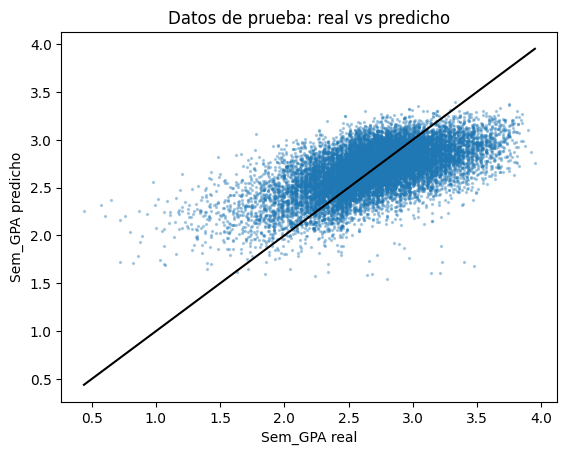

In [19]:
plt.figure()
plt.scatter(Y_prueba, Y_predicha_de_prueba, s=2, alpha=0.3)
plt.plot([Y_prueba.min(), Y_prueba.max()], [Y_prueba.min(), Y_prueba.max()], color='black')
plt.xlabel('Sem_GPA real')
plt.ylabel('Sem_GPA predicho')
plt.title('Datos de prueba: real vs predicho')
plt.show()

**Conclusiones**

El modelo de regresión lineal logra captar una relación real entre las variables elegidas y el promedio del semestre, pero de forma moderada: explica alrededor del 36% de la variación del promedio (R2 = 0,36) y se equivoca en promedio por 0,26 puntos sobre una escala de 0 a 4.

Las variables con mayor peso en la predicción fueron las visitas de tutoría, las materias desaprobadas y el estrés financiero (coeficientes negativos), junto con los ingresos al campus virtual y la asistencia (coeficientes positivos). Esto coincide con lo que se vio en el análisis exploratorio: ninguna variable por sí sola tenía una correlación fuerte con el promedio, lo cual anticipaba que el modelo no iba a lograr un ajuste muy alto.

En el gráfico de real vs. predicho se observa que el modelo tiende a subestimar a los estudiantes con promedios muy altos y a sobreestimar a los de promedios muy bajos: las predicciones se concentran entre 2 y 3,4, mientras que los valores reales van de 0,5 a 4. Esto es esperable en una regresión lineal cuando el fenómeno a predecir depende de muchos factores que no están en el dataset (por ejemplo, motivación, calidad de la enseñanza, situación personal), y que un modelo lineal simple no puede capturar del todo.

Como limitación, vale aclarar que el dataset es longitudinal (varias filas por estudiante) y que se separaron los datos manteniendo el orden en vez de mezclarlos al azar, para evitar que el mismo estudiante apareciera en entrenamiento y en prueba.